## This section is a backlog of things I did earlier in the pipeline, part of the iterative process
1. Generate the first iteration of the db that was put into Logan (PVDB1)
    * intermediate files and products
2. HMM generation <- we are here
    * download PAVE sequences, generate first version of the L1 hmms
    * updating this HMM with the NCBI L1 sequences (+ncbi characterization)
    * another iteration with the novel sequences from the first iteration

In [1]:
%load_ext rpy2.ipython
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
#misc setup, honestly idk if i need these but it worked last time.

In [ ]:
%%bash
#p2, download PAVE sequences, generate first version of the L1 hmms
#generate L1 hmm from the PAVE proteins
#download L1 proteins from PAVE, as of 2024.07.30
#sort and generate MSA
seqkit sort -l -r L1_pave_protein.fa > L1_pave_protein_sort.fa
usearch --cluster_smallmem unannotated_clean_full_sorted.fa -id 0.90 -centroids L1_pave_protein_centroids.fa -uc L1_pave_protein_clusters.uc
muscle5.1.linux_intel64 -super5 L1_pave_protein_centroids.fa -output L1_pave_protein_super5.aln

#trim manually in jalview, for different JR regions
#see files L1_[region]_super5.aln for coordinates

#convert all of these alignment files to stockholm, in order to generate profile hmms
esl-reformat stockholm L1_I_super5.aln > L1_I_super5.sto
esl-reformat stockholm L1_B_super5.aln > L1_B_super5.sto
esl-reformat stockholm L1_CD_super5.aln > L1_CD_super5.sto
esl-reformat stockholm L1_E_super5.aln > L1_E_super5.sto
esl-reformat stockholm L1_F_super5.aln > L1_F_super5.sto
esl-reformat stockholm L1_GH_super5.aln > L1_GH_super5.sto

#build into hmm profiles
hmmbuild L1_I_super5.hmm L1_I_super5.sto
hmmbuild L1_B_super5.hmm L1_B_super5.sto
hmmbuild L1_CD_super5.hmm L1_CD_super5.sto
hmmbuild L1_E_super5.hmm L1_E_super5.sto
hmmbuild L1_F_super5.hmm L1_F_super5.sto
hmmbuild L1_GH_super5.hmm L1_GH_super5.sto

#combine into 1 hmm, so that can run all of them at once
cat L1_I_super5.hmm L1_B_super5.hmm L1_CD_super5.hmm L1_E_super5.hmm L1_F_super5.hmm L1_GH_super5.hmm > L1_JR_super5.hmm

In [ ]:
%%bash
#p2, updating above HMM with the NCBI L1 sequences (+ncbi characterization)
#from NCBI downloaded sequences, 2024.08.06_all_PV_annotated_on_ncbi.fasta
#get orfs
getorf -sequence 2024.08.06_all_PV_annotated_on_ncbi.fasta -outseq all_ncbi_pv_sto_sto.fa -find 0  

#some parsing to get rid of special characters and other things that mess up the downstream process
#the NC is for parsing on certain number of underscores, just makes life a bit easier
sed -i.bak -e 's/ /_/g' -e 's/[][]//g' -e 's/-//g' -e 's/__/_/g' -e 's/[)()]//g' -e 's/NC_/NC+/' all_ncbi_pv_sto_sto.fa

#prune sequences that have NNNs
#roundabout way to do it
sed -i.bak '/^>/! s/X/!/g' "/home/rnalab/js/ncbi_character/all_ncbi_pv_sto_sto.fa"
#remove sequences that have 1 or more ! masked characters
seqkit fx2tab all_ncbi_pv_sto_sto.fa | awk -F'!' 'NF<=1'  | seqkit tab2fx > all_ncbi_pv_sto_sto_pruned.fa

#run against the hmm generated above
hmmsearch --F1 0.01 -T 20 --domtblout all_ncbi_pv_sto_sto_pruned.domtbl "/home/rnalab/js/hmms/L1_JR_super5.hmm" all_ncbi_pv_sto_sto_pruned.fa

In [ ]:
%%R
# Bioconductor version
install.packages("BiocManager", dependencies=TRUE, repos='http://cran.rstudio.com/')

library(BiocManager)
BiocManager::install("ggtree")

# github version
devtools::install_github("YuLab-SMU/ggtree")
#characterizing the L1 sequences on NCBI
# install.packages("gggenes", dependencies=TRUE, repos='http://cran.rstudio.com/')

library(tidyverse)
library(gggenes)

#function for parsing hmmsearch outputs
hmmsearch_clean <- function(input_domtbl){
  input_domtbl_scan <- read.table(input_domtbl, sep = "",  header = F, fill = T) %>% na.omit() %>% .[,1:22]
  input_domtbl_scan <- input_domtbl_scan[!(is.na(input_domtbl_scan$V21) | input_domtbl_scan$V21=="" | !(input_domtbl_scan$V2 == "-")), ]
  
  colnames(input_domtbl_scan) <- c("query_acc", "misc", "qlen", "pfam", "pfam_acc", "tlen", "eval_full", "score_full", "bias_full", "#", "of", 
                                   "c_eval", "i_eval", "score_one", "bias_one", "hmmcoord_from", "hmmcoord_to", "alicoord_from", "alicoord_to", "envcoord_from", "envcoord_to", "acc")
  input_domtbl_scan$query_acc_clean <- sub("_[^_]+$", "", input_domtbl_scan$query_acc)
  input_domtbl_scan <- type.convert(input_domtbl_scan, as.is = TRUE)
  return(input_domtbl_scan)
}

all_ncbi_pv_sto_sto <- hmmsearch_clean("all_ncbi_pv_sto_sto_pruned.domtbl")
#reparse some stuff based on new contig formatting
all_ncbi_pv_sto_sto$contig_orf <- sub("([A-Za-z0-9]+_[A-Za-z0-9]+).*", "\\1", all_ncbi_pv_sto_sto$query_acc)
all_ncbi_pv_sto_sto$contig <- sub("_[^_]+$", "", all_ncbi_pv_sto_sto$contig_orf)
#find the start and stop positions of nucleotides
all_ncbi_pv_sto_sto$query_acc_clean <- sub("_$","",all_ncbi_pv_sto_sto$query_acc_clean)

all_ncbi_pv_sto_sto <- all_ncbi_pv_sto_sto %>% extract(query_acc_clean, into = c("query_acc_clean", "orf_end"), "(.*)_([^_]+)$")
all_ncbi_pv_sto_sto <- all_ncbi_pv_sto_sto %>% extract(query_acc_clean, into = c("query_acc_clean", "orf_start"), "(.*)_([^_]+)$")
all_ncbi_pv_sto_sto <- all_ncbi_pv_sto_sto %>% extract(query_acc_clean, into = c("query_acc_clean", "orf"), "(.*)_([^_]+)$")

#define direction of orf
all_ncbi_pv_sto_sto[25:26] <- lapply(all_ncbi_pv_sto_sto[,25:26], as.numeric) 
all_ncbi_pv_sto_sto$direction <- ifelse(all_ncbi_pv_sto_sto$orf_start > all_ncbi_pv_sto_sto$orf_end, "rev", "fw")

#split into different dfs for each pfam model
all_ncbi_pv_sto_sto_split <- split(all_ncbi_pv_sto_sto, all_ncbi_pv_sto_sto$pfam)

#start with those that have B and I domains
all_ncbi_pv_sto_sto_BI <- inner_join(all_ncbi_pv_sto_sto_split$L1_B_super5, all_ncbi_pv_sto_sto_split$L1_I_super5, by='query_acc_clean')
NCBI_BI_contigs <- all_ncbi_pv_sto_sto_BI$query_acc_clean
#this dataframe then has the orfs that have identifiable B and I domains
all_ncbi_pv_sto_sto_BI_orfs <- all_ncbi_pv_sto_sto_BI[all_ncbi_pv_sto_sto_BI$query_acc.x == all_ncbi_pv_sto_sto_BI$query_acc.y, ]

#look for genes that have weird patterns and visualize it

#################################first, orfs that have separated B and I (eg, on different ORFs)
all_ncbi_pv_sto_sto_BI_seporf <- all_ncbi_pv_sto_sto_BI[all_ncbi_pv_sto_sto_BI$query_acc.x != all_ncbi_pv_sto_sto_BI$query_acc.y,]

sep_orfs <- all_ncbi_pv_sto_sto_BI_seporf$query_acc_clean

all_ncbi_pv_sto_sto_B_coords <- filter(all_ncbi_pv_sto_sto_split$L1_B_super5, query_acc_clean %in% sep_orfs)
all_ncbi_pv_sto_sto_I_coords <- filter(all_ncbi_pv_sto_sto_split$L1_I_super5, query_acc_clean %in% sep_orfs)

all_ncbi_pv_sto_sto_BI_coords <- rbind(all_ncbi_pv_sto_sto_B_coords, all_ncbi_pv_sto_sto_I_coords)
# all_ncbi_pv_sto_sto_BI_coords <- select(all_ncbi_pv_sto_sto_BI_coords, query_acc_clean, orf_start, orf_end, pfam)

all_ncbi_pv_sto_sto_BI_coords$orf_start <- as.numeric(all_ncbi_pv_sto_sto_BI_coords$orf_start)
all_ncbi_pv_sto_sto_BI_coords$orf_end <- as.numeric(all_ncbi_pv_sto_sto_BI_coords$orf_end)
all_ncbi_pv_sto_sto_BI_coords$nuc_start <- all_ncbi_pv_sto_sto_BI_coords$envcoord_to*2 + (all_ncbi_pv_sto_sto_BI_coords$envcoord_from - 3) + all_ncbi_pv_sto_sto_BI_coords$orf_start
all_ncbi_pv_sto_sto_BI_coords$nuc_end <- (all_ncbi_pv_sto_sto_BI_coords$envcoord_from*3 - 1) + all_ncbi_pv_sto_sto_BI_coords$orf_start

p <- ggplot(all_ncbi_pv_sto_sto_BI_coords, aes(xmin = orf_start, xmax = orf_end, y = query_acc_clean)) +
  geom_gene_arrow(aes(alpha = 0.5)) +
  geom_subgene_arrow(data = all_ncbi_pv_sto_sto_BI_coords,
                     aes(xmin = orf_start, xmax = orf_end, y = query_acc_clean, fill = pfam,
                         xsubmin = nuc_start, xsubmax = nuc_end), color="black", alpha=.7) +
  facet_wrap(~ query_acc_clean, scales = "free", ncol = 1) +
  scale_fill_brewer(palette = "Set3") +
  theme_genes()

ggsave("orfs_updated.pdf", width = 20, height = 20, limitsize = FALSE)
#some errors, cause the genes are not perfectly on 2 contigs like that

* installing *source* package ‘remotes’ ...
** package ‘remotes’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (remotes)
* installing *source* package ‘BiocManager’ ...
** package ‘BiocManager’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a rec

x86_64-conda-linux-gnu-cc -I"/home/jshen/anaconda3/lib/R/include" -DNDEBUG   -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /home/jshen/anaconda3/include -I/home/jshen/anaconda3/include -Wl,-rpath-link,/home/jshen/anaconda3/lib    -fpic  -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /home/jshen/anaconda3/include -fdebug-prefix-map=/workspace/croot/r-base_1695428141831/work=/usr/local/src/conda/r-base-4.3.1 -fdebug-prefix-map=/home/jshen/anaconda3=/usr/local/src/conda-prefix  -c expr.c -o expr.o
x86_64-conda-linux-gnu-cc -I"/home/jshen/anaconda3/lib/R/include" -DNDEBUG   -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /home/jshen/anaconda3/include -I/home/jshen/anaconda3/include -Wl,-rpath-link,/home/jshen/anaconda3/lib    -fpic  -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /home/jshen/anaconda3/include -fdebug-prefix-map=/workspace/croot/r-

installing to /home/jshen/anaconda3/lib/R/library/00LOCK-lazyeval/00new/lazyeval/libs
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (lazyeval)
* installing *source* package ‘ape’ ...
** package ‘ape’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘x86_64-conda-linux-gnu-cc (Anaconda gcc) 11.2.0’
using C++ compiler: ‘x86_64-conda-linux-gnu-c++ (Anaconda gcc) 11.2.0’


x86_64-conda-linux-gnu-cc -I"/home/jshen/anaconda3/lib/R/include" -DNDEBUG  -I'/home/jshen/anaconda3/lib/R/library/Rcpp/include' -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /home/jshen/anaconda3/include -I/home/jshen/anaconda3/include -Wl,-rpath-link,/home/jshen/anaconda3/lib    -fpic  -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /home/jshen/anaconda3/include -fdebug-prefix-map=/workspace/croot/r-base_1695428141831/work=/usr/local/src/conda/r-base-4.3.1 -fdebug-prefix-map=/home/jshen/anaconda3=/usr/local/src/conda-prefix  -c BIONJ.c -o BIONJ.o
x86_64-conda-linux-gnu-cc -I"/home/jshen/anaconda3/lib/R/include" -DNDEBUG  -I'/home/jshen/anaconda3/lib/R/library/Rcpp/include' -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /home/jshen/anaconda3/include -I/home/jshen/anaconda3/include -Wl,-rpath-link,/home/jshen/anaconda3/lib    -fpic  -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -

installing to /home/jshen/anaconda3/lib/R/library/00LOCK-ape/00new/ape/libs
** R
** data
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (ape)
* installing *source* package ‘yulab.utils’ ...
** package ‘yulab.utils’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of tempora

...

checking for a BSD-compatible install... /usr/bin/install -c
checking whether build environment is sane... yes
checking for a thread-safe mkdir -p... /usr/bin/mkdir -p
checking for gawk... gawk
checking whether make sets $(MAKE)... yes
checking whether make supports nested variables... yes
checking whether UID '1000' is supported by ustar format... yes
checking whether GID '1000' is supported by ustar format... yes
checking how to create a ustar tar archive... gnutar
checking whether make supports nested variables... (cached) yes
checking for x86_64-conda-linux-gnu-gcc... x86_64-conda-linux-gnu-cc
checking whether the C compiler works... yes
checking for C compiler default output file name... a.out
checking for suffix of executables... 
checking whether we are cross compiling... no
checking for suffix of object files... o
checking whether we are using the GNU C compiler... yes
checking whether x86_64-conda-linux-gnu-cc accepts -g... yes
checking for x86_64-conda-linux-gnu-cc option to 

configure: WARNING: --without-documentation is DEPRECATED and will be removed in the next release, use --without-docs


yes
checking limits.h presence... yes
checking for limits.h... yes
checking stddef.h usability... yes
checking stddef.h presence... yes
checking for stddef.h... yes
checking for stdlib.h... (cached) yes
checking for string.h... (cached) yes
checking arpa/inet.h usability... yes
checking arpa/inet.h presence... yes
checking for arpa/inet.h... yes
checking netinet/tcp.h usability... yes
checking netinet/tcp.h presence... yes
checking for netinet/tcp.h... yes
checking netinet/in.h usability... yes
checking netinet/in.h presence... yes
checking for netinet/in.h... yes
checking sys/socket.h usability... yes
checking sys/socket.h presence... yes
checking for sys/socket.h... yes
checking sys/time.h usability... yes
checking sys/time.h presence... yes
checking for sys/time.h... yes
checking ifaddrs.h usability... yes
checking ifaddrs.h presence... yes
checking for ifaddrs.h... yes
checking sys/uio.h usability... yes
checking sys/uio.h presence... yes
checking for sys/uio.h... yes
checking whet

configure: WARNING: Cannot find libunwind


config.status: creating Makefile
config.status: creating src/libzmq.pc
config.status: creating src/platform.hpp
config.status: executing depfiles commands
config.status: executing libtool commands
make[1]: Entering directory '/tmp/RtmpNI6Doa/R.INSTALL52981a6150fc/pbdZMQ/src/zmqsrc'
make[2]: Entering directory '/tmp/RtmpNI6Doa/R.INSTALL52981a6150fc/pbdZMQ/src/zmqsrc'
  CXX      src/src_libzmq_la-address.lo
  CXX      src/src_libzmq_la-client.lo
  CXX      src/src_libzmq_la-clock.lo
  CXX      src/src_libzmq_la-ctx.lo
  CXX      src/src_libzmq_la-curve_client.lo
  CXX      src/src_libzmq_la-curve_server.lo
  CXX      src/src_libzmq_la-dealer.lo
  CXX      src/src_libzmq_la-devpoll.lo
  CXX      src/src_libzmq_la-dgram.lo
  CXX      src/src_libzmq_la-dish.lo
  CXX      src/src_libzmq_la-dist.lo
  CXX      src/src_libzmq_la-epoll.lo
  CXX      src/src_libzmq_la-err.lo
  CXX      src/src_libzmq_la-fq.lo
  CXX      src/src_libzmq_la-gather.lo
  CXX      src/src_libzmq_la-gssapi_mechanism_bas

In [18]:
class PDF(object):
  def __init__(self, pdf, size=(200,200)):
    self.pdf = pdf
    self.size = size

  def _repr_html_(self):
    return '<iframe src={0} width={1[0]} height={1[1]}></iframe>'.format(self.pdf, self.size)

  def _repr_latex_(self):
    return r'\includegraphics[width=1.0\textwidth]{{{0}}}'.format(self.pdf)


PDF('orfs_updated.pdf',size=(1000,250))

## Misc features and notekeeping

while i was looking through the data, came across a segmented (?) L1 capsid
missing the fuchsia strand, which was in another orf - premature stop or low quality genome? https://www.ncbi.nlm.nih.gov/nuccore/KU684312.1
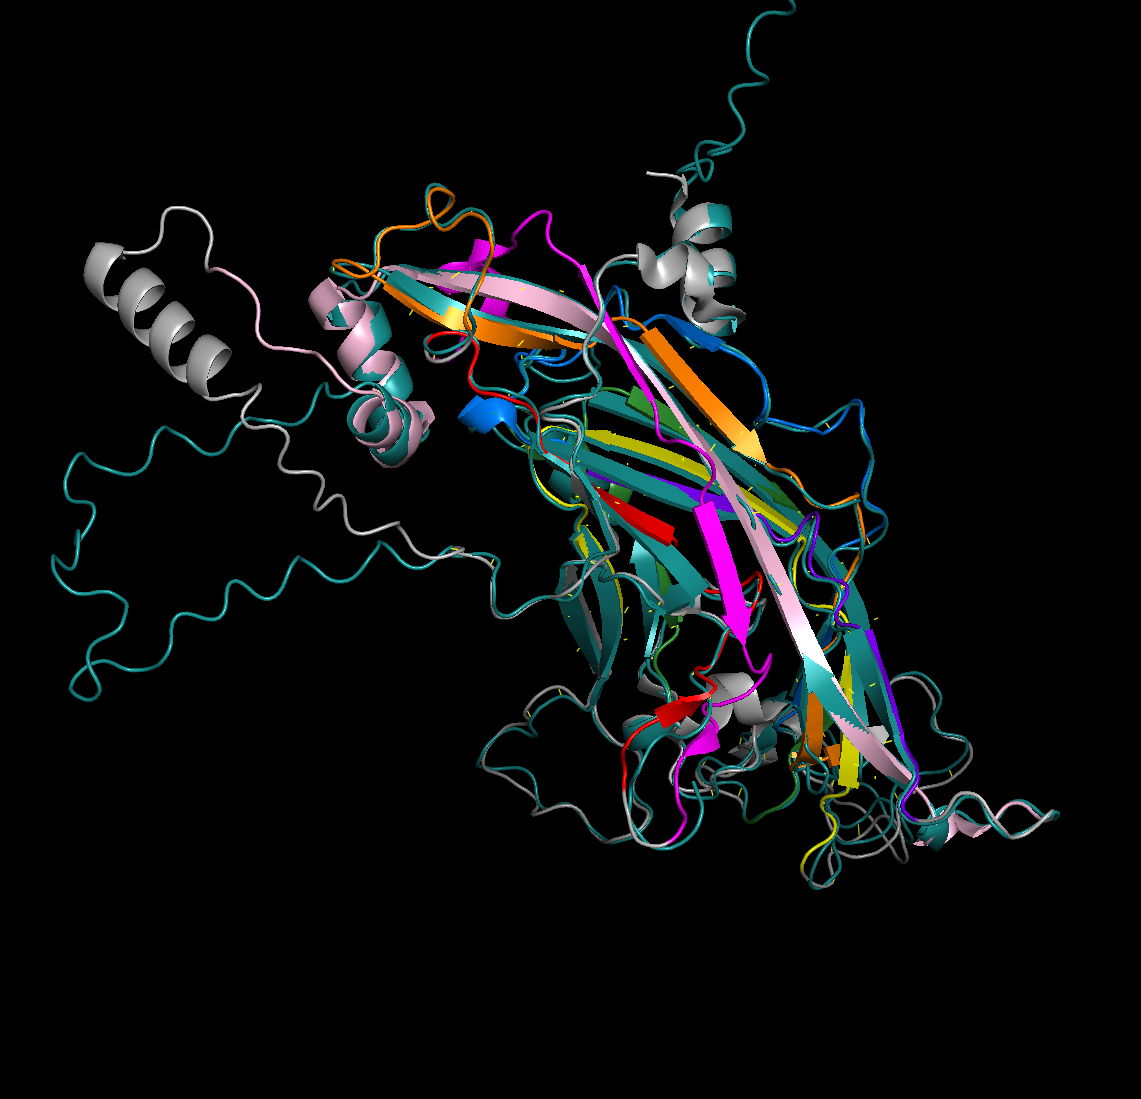

when compared to closest HPV16 sequence, looks like its a single nucleotide error in this position, I'll probably throw this out
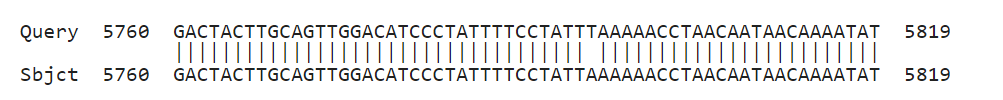

looks like there are actually fish papillomas that have a experimentally confirmed indel/splice site: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5021401/, some of the PVs related to fish picked up above will probably have indels as well, it looks like.

I think the game plan for these NCBI sequences will be some manual curation, separated into either:
1. biologically relevant (eg. splice sites in the fish sequences, PPxxxx sequencing runs)
2. Likely single nucleotide error or snp (removed)
(Essentially building a case for each category/grouping)


## blacklist file
   * Ignoring the "split" L1s by putting them into a blacklist see blacklist.txt

In [19]:
%%R
###############look for possible inversions
##split based on fw and rev
all_ncbi_pv_sto_sto_fr_split <- split(all_ncbi_pv_sto_sto, all_ncbi_pv_sto_sto$direction)

all_ncbi_pv_sto_sto_fr_split_contigs <- purrr::reduce(all_ncbi_pv_sto_sto_fr_split, dplyr::inner_join, by = 'contig')

#get contigs that are common between the two split dfs
fw_rev_contigs <- unique(all_ncbi_pv_sto_sto_fr_split$contig)

#start with forward contigs and start of regions
func1 <- function(x) head(x,1)   # if duplicate, use first value
all_ncbi_pv_sto_sto_order_start_fw <- aggregate(all_ncbi_pv_sto_sto_fr_split$fw[c("envcoord_from")], by=list(contig=all_ncbi_pv_sto_sto_fr_split$fw$contig,pfam=all_ncbi_pv_sto_sto_fr_split$fw$pfam), func1)

all_ncbi_pv_sto_sto_order_start_fw <- reshape(all_ncbi_pv_sto_sto_order_start_fw, idvar = "contig", timevar = "pfam", direction = "wide") %>%
  filter(., contig %in% NCBI_BI_contigs)
#warning, grab first B occurrence which is fine

#for end
func2 <- function(x) tail(x,1)   # if duplicate, use last value
all_ncbi_pv_sto_sto_order_end_fw <- aggregate(all_ncbi_pv_sto_sto_fr_split$fw[c("envcoord_to")], by=list(contig=all_ncbi_pv_sto_sto_fr_split$fw$contig,pfam=all_ncbi_pv_sto_sto_fr_split$fw$pfam), func2)

all_ncbi_pv_sto_sto_order_end_fw <- reshape(all_ncbi_pv_sto_sto_order_end_fw, idvar = "contig", timevar = "pfam", direction = "wide") %>%
  filter(., contig %in% NCBI_BI_contigs)

#look for regions that are/not in the right order
#this is from known false positives, Ignoring the "split" L1s by putting them into a blacklist and filtering out, there are surprisingly (or maybe not?) 0 reordering of the domains
blacklist <- read.table("blacklist.txt", header = F)
all_ncbi_pv_sto_sto_order_start_fw_clean <- filter(all_ncbi_pv_sto_sto_order_start_fw, !contig %in% blacklist$V1)
all_ncbi_pv_sto_sto_order_CD_B <- filter(all_ncbi_pv_sto_sto_order_start_fw_clean, envcoord_from.L1_B_super5 > envcoord_from.L1_CD_super5)
all_ncbi_pv_sto_sto_order_E_CD <- filter(all_ncbi_pv_sto_sto_order_start_fw_clean, envcoord_from.L1_CD_super5 > envcoord_from.L1_E_super5)
all_ncbi_pv_sto_sto_order_F_E <- filter(all_ncbi_pv_sto_sto_order_start_fw_clean, envcoord_from.L1_E_super5 > envcoord_from.L1_F_super5)
all_ncbi_pv_sto_sto_order_GH_F <- filter(all_ncbi_pv_sto_sto_order_start_fw_clean, envcoord_from.L1_F_super5 > envcoord_from.L1_GH_super5)
all_ncbi_pv_sto_sto_order_I_GH <- filter(all_ncbi_pv_sto_sto_order_start_fw_clean, envcoord_from.L1_GH_super5 > envcoord_from.L1_I_super5)

##for reverse contigs
all_ncbi_pv_sto_sto_order_start_rev <- aggregate(all_ncbi_pv_sto_sto_fr_split$rev[c("envcoord_from")], by=list(contig=all_ncbi_pv_sto_sto_fr_split$rev$contig,pfam=all_ncbi_pv_sto_sto_fr_split$rev$pfam), func1)

all_ncbi_pv_sto_sto_order_start_rev <- reshape(all_ncbi_pv_sto_sto_order_start_rev, idvar = "contig", timevar = "pfam", direction = "wide") %>%
  filter(., contig %in% NCBI_BI_contigs)

all_ncbi_pv_sto_sto_order_end_rev <- aggregate(all_ncbi_pv_sto_sto_fr_split$rev[c("envcoord_to")], by=list(contig=all_ncbi_pv_sto_sto_fr_split$rev$contig,pfam=all_ncbi_pv_sto_sto_fr_split$rev$pfam), func2)

all_ncbi_pv_sto_sto_order_end_rev <- reshape(all_ncbi_pv_sto_sto_order_end_rev, idvar = "contig", timevar = "pfam", direction = "wide") %>%
  filter(., contig %in% NCBI_BI_contigs)

all_ncbi_pv_sto_sto_order_start_rev_clean <- filter(all_ncbi_pv_sto_sto_order_start_rev, !contig %in% blacklist$V1)
all_ncbi_pv_sto_sto_order_rev_CD_B <- filter(all_ncbi_pv_sto_sto_order_start_rev_clean, envcoord_from.L1_B_super5 > envcoord_from.L1_CD_super5)
all_ncbi_pv_sto_sto_order_rev_E_CD <- filter(all_ncbi_pv_sto_sto_order_start_rev_clean, envcoord_from.L1_CD_super5 > envcoord_from.L1_E_super5)
all_ncbi_pv_sto_sto_order_rev_F_E <- filter(all_ncbi_pv_sto_sto_order_start_rev_clean, envcoord_from.L1_E_super5 > envcoord_from.L1_F_super5)
all_ncbi_pv_sto_sto_order_rev_GH_F <- filter(all_ncbi_pv_sto_sto_order_start_rev_clean, envcoord_from.L1_F_super5 > envcoord_from.L1_GH_super5)
all_ncbi_pv_sto_sto_order_rev_I_GH <- filter(all_ncbi_pv_sto_sto_order_start_rev_clean, envcoord_from.L1_GH_super5 > envcoord_from.L1_I_super5)

##############################expand this concept to all the jellyroll regions, look for "coverage" ##############################
all_ncbi_pv_sto_sto_bare <- select(all_ncbi_pv_sto_sto, contig, pfam)
all_ncbi_pv_sto_sto_bare <- all_ncbi_pv_sto_sto_bare %>%
  mutate(pres = 1)

func3 <- function(x) {ifelse(length(x)==1,as.character(x), length(x))}
all_ncbi_pv_sto_sto_bare_long <- aggregate(all_ncbi_pv_sto_sto_bare[c("pres")], by=list(contig=all_ncbi_pv_sto_sto_bare$contig,pfam=all_ncbi_pv_sto_sto_bare$pfam), func3)
all_ncbi_pv_sto_sto_bare_long$pres <- as.numeric(all_ncbi_pv_sto_sto_bare_long$pres)
all_ncbi_pv_sto_sto_bare_long <- filter(all_ncbi_pv_sto_sto_bare_long, !contig %in% blacklist$V1)

##try this with all domains
all_ncbi_pv_sto_sto_bare_long_all <- all_ncbi_pv_sto_sto_bare_long

all_ncbi_pv_sto_sto_bare_long_all <- reshape(all_ncbi_pv_sto_sto_bare_long_all, idvar = "contig", timevar = "pfam", direction = "wide")
all_ncbi_pv_sto_sto_bare_long_all[is.na(all_ncbi_pv_sto_sto_bare_long_all)] <- 0

all_ncbi_pv_sto_sto_bare_long_all_mat <- as.matrix(all_ncbi_pv_sto_sto_bare_long_all)
rownames(all_ncbi_pv_sto_sto_bare_long_all_mat) <- all_ncbi_pv_sto_sto_bare_long_all$contig
all_ncbi_pv_sto_sto_bare_long_all_mat <- all_ncbi_pv_sto_sto_bare_long_all_mat[,2:7]

all_ncbi_pv_sto_sto_bare_long_all_den <- as.dendrogram(hclust(d = dist(x = all_ncbi_pv_sto_sto_bare_long_all_mat)))
order_all <- order.dendrogram(all_ncbi_pv_sto_sto_bare_long_all_den)

all_ncbi_pv_sto_sto_bare_long_all$contig <- factor(x = all_ncbi_pv_sto_sto_bare_long_all$contig,
                                                   levels = all_ncbi_pv_sto_sto_bare_long_all$contig[order_all], 
                                                   ordered = TRUE)

l <- all_ncbi_pv_sto_sto_bare_long %>% 
  ggplot(aes(x = factor(pfam), y = contig)) +
  geom_tile(aes(fill = pres, color = pfam), size = 0.5) +
  scale_color_brewer(palette = "Set3") +
  theme_bw() +
  theme(axis.ticks.y.left = element_blank())

ggsave("domains_BI_all_dendro.pdf", width = 10, height = 1000, limitsize = FALSE)

#look at if B and I are missing using length based calculation
#first look at things with CD hits, and a possible B based on how much room there is in the orf/contig

# All of the sequences that have the B and I domains on separate ORFs have been categorized now
# with most of the them falling under presumed technical error or one off.

# For the other sequences, I've more or less been able to reconstruct a full L1 by  predicting splice sites and joining the two ORFs together with some preliminary webtools while i try to get spliceAI setup.
# Definitely took longer than I would've liked but i needed to do a lot of staring at nucleotide sequences (unpleasant)

In [20]:
PDF('domains_BI_all_dendro.pdf',size=(250,1000))

## Checkpoint
 1. Reiterate the MSA -> new HMM to hopefully get more sensitivity
    * a) Subgoal: look for sequences that might have B/I missing using a contig-length based strategy
2. Re-run MSA
3. ???
4. get amino acid sequences for all NCBI L1s

In [21]:
%%R
# working on 1(a), there seems to be around 6-7 full L1 contigs in which my L1_B model failed - I filtered for these by looking at orfs > 30 aa in size, and if the start of the alignment for the CD region was greater than 15 aa downstream of orf start. 
# then filtered for contigs that had no B model hit (removing the known splice/error list)

all_ncbi_pv_sto_sto_30len_CD <- filter(all_ncbi_pv_sto_sto, qlen > 30 & envcoord_from > 15 & pfam == "L1_CD_super5" & !contig %in% all_ncbi_pv_sto_sto_split$L1_B_super5$contig & !contig %in% blacklist$V1)
write.table( all_ncbi_pv_sto_sto_30len_CD$contig, "ncbi_B_misses.txt", quote = F, col.names = F, row.names = F)

ggplot(all_ncbi_pv_sto_sto_30len_CD, aes(xmin = 1, xmax = qlen, y = query_acc_clean)) +
  geom_gene_arrow(aes(alpha = 0.5)) +
  geom_subgene_arrow(data = all_ncbi_pv_sto_sto_30len_CD,
                     aes(xmin = 1, xmax = qlen, y = query_acc_clean, fill = pfam,
                         xsubmin = envcoord_from, xsubmax = envcoord_to), color="black", alpha=.7) +
  facet_wrap(~ query_acc_clean, scales = "free", ncol = 1) +
  scale_x_continuous(labels = scales::comma, limits = c(1, 510)) + 
  scale_fill_brewer(palette = "Set1") +
  theme_genes()

ggsave("domains_B_fail.pdf", width = 10, height = 20, limitsize = FALSE)

#now look at GH domains for "space" after the hit
all_ncbi_pv_sto_sto_30len_GH <- all_ncbi_pv_sto_sto
all_ncbi_pv_sto_sto_30len_GH$tail <- all_ncbi_pv_sto_sto_30len_GH$qlen - all_ncbi_pv_sto_sto_30len_GH$envcoord_to
all_ncbi_pv_sto_sto_30len_GH <- filter(all_ncbi_pv_sto_sto_30len_GH, qlen > 30 & tail > 15 & pfam == "L1_GH_super5" & !contig %in% all_ncbi_pv_sto_sto_split$L1_I_super5$contig & !contig %in% blacklist$V1)

ggplot(all_ncbi_pv_sto_sto_30len_GH, aes(xmin = 1, xmax = qlen, y = query_acc_clean)) +
  geom_gene_arrow(aes(alpha = 0.5)) +
  geom_subgene_arrow(data = all_ncbi_pv_sto_sto_30len_GH,
                     aes(xmin = 1, xmax = qlen, y = query_acc_clean, fill = pfam,
                         xsubmin = envcoord_from, xsubmax = envcoord_to), color="black", alpha=.7) +
  facet_wrap(~ query_acc_clean, scales = "free", ncol = 1) +
  scale_x_continuous(labels = scales::comma, limits = c(1, 510)) + 
  scale_fill_brewer(palette = "PRGn") +
  theme_genes()

ggsave("domains_I_fail.pdf", width = 10, height = 30, limitsize = FALSE)

#so i can assume the ones that are really short = fragments, and manually add the curated ones to the msa that are missing
# accession	note	missing
# BK066313.1	MAG TPA_asm: Papillomavirus rana6035 isolate Papilloma6035 genomic sequence	B
# BK066841.1	MAG TPA_asm: Papillomavirus rana5986 isolate Papilloma5986 genomic sequence	B
# BK066884.1	MAG TPA_asm: Papillomavirus ambystoma6078 isolate Papilloma6078 genomic sequence	B
# BK066894.1	MAG TPA_asm: Papillomavirus rana5702 isolate Papilloma5702 genomic sequence	B
# MZ244208.1	MAG: Urolophus aurantiacus papillomavirus 1 isolate cxx4 L1 and E1 genes, complete cds	B
# PP711991.1	MAG: Eidolon bat papillomavirus isolate 3A/Kenya/BAT613/2015 genomic sequence	I

#group definitions
# 1. Low hanging fruit/sequences that are well behaved
# 2. Sequences that have regions not picked up by HMMs
# 3. Spliced sequences (manually identified and added)

#finally... after trials and tribulations, we can extract the B and I domain
# From here I think I can tackle 1), which is to extract the amino acid sequences from the start of B to the end of I (including the manually added/spliced sequences, and PAVE), generate an MSA, then finally a new HMM to capture the regions (then do a re-annotation to see if the missing regions have been filled out)
#tackle the easy task first of getting the ones that have B and I hits on the same orf
all_ncbi_pv_sto_sto_BI_orfs_clean <- filter(all_ncbi_pv_sto_sto_BI_orfs, !contig.x %in% blacklist$V1 & !contig.y %in% blacklist$V1)
BI_contigs <- all_ncbi_pv_sto_sto_BI_orfs_clean$query_acc.x

all_ncbi_pv_sto_sto_BI_info <- filter(all_ncbi_pv_sto_sto, query_acc %in% BI_contigs)

#manually add those that are misses
#see "ncbi_clean.xlsx"
p2_add <- c("BK066313.1_121_4075_5487_", "BK066841.1_119_4136_5596_", "BK066884.1_125_4254_5780_", "BK066894.1_125_3999_5450_", "MZ244208.1_35_175_1623_", "PP711991.1_136_5827_7023_")
all_ncbi_pv_sto_sto_p2 <- filter(all_ncbi_pv_sto_sto, query_acc %in% p2_add)

all_ncbi_pv_sto_sto_L1_envcoord_from <- all_ncbi_pv_sto_sto_BI_info %>% group_by(query_acc) %>% slice_min(n = 1, envcoord_from)
all_ncbi_pv_sto_sto_L1_envcoord_from <- select(all_ncbi_pv_sto_sto_L1_envcoord_from, query_acc, envcoord_from)

all_ncbi_pv_sto_sto_L1_envcoord_to <- all_ncbi_pv_sto_sto_BI_info %>% group_by(query_acc) %>% slice_max(n = 1, envcoord_to)
all_ncbi_pv_sto_sto_L1_envcoord_to <- select(all_ncbi_pv_sto_sto_L1_envcoord_to, query_acc, envcoord_to)

all_ncbi_pv_sto_sto_L1_envcoords <- left_join(all_ncbi_pv_sto_sto_L1_envcoord_from, all_ncbi_pv_sto_sto_L1_envcoord_to, by = "query_acc")
all_ncbi_pv_sto_sto_L1_envcoords <- unique(all_ncbi_pv_sto_sto_L1_envcoords)
all_ncbi_pv_sto_sto_L1_envcoords_envaa <- select(all_ncbi_pv_sto_sto_L1_envcoords, query_acc, envcoord_from, envcoord_to)

all_ncbi_pv_sto_sto_L1_envcoords_envaa$nuc_from <- all_ncbi_pv_sto_sto_L1_envcoords_envaa$envcoord_from*2 + (all_ncbi_pv_sto_sto_L1_envcoords_envaa$envcoord_from - 3)
all_ncbi_pv_sto_sto_L1_envcoords_envaa$nuc_to <- all_ncbi_pv_sto_sto_L1_envcoords_envaa$envcoord_to*3 - 1
write.table(select(all_ncbi_pv_sto_sto_L1_envcoords_envaa, query_acc, nuc_from, nuc_to), "all_ncbi_pv_sto_sto_L1_envcoords_p1.txt", quote = F, col.names = F, row.names = F, sep = "\t")

In [27]:
PDF('domains_B_fail.pdf',size=(500,300))
PDF('domains_I_fail.pdf',size=(500,300))

In [2]:
%%bash
#extract the L1 coords from above, and also cat the p2 sequences
awk 'OFS="\t" {if($2>$3) print $1, $3-1, $2, ".", ".", "-"; else print $1, $2-1, $3, ".", ".", "+"}'  ncbi_character/all_ncbi_pv_sto_sto_L1_envcoords_p1.txt | bedtools getfasta -s -fi "/home/rnalab/js/ncbi_character/all_ncbi_pv_sto_sto_pruned.fa" -bed - > ncbi_L1_p1.fa
#manual generation of p3 seqsm, see "splices.txt"
cat ncbi_L1_p1.fa ncbi_p2_seqs.fa ncbi_p3_seqs.fa > ncbi_p1_2_3.fa
# #sort, cluster, align, sanity check
# seqkit sort -l -r ncbi_p1_2_3.fa > ncbi_p1_2_3_sort.fa
# usearch11.0.667_i86linux32 --cluster_smallmem ncbi_p1_2_3_sort.fa -id 0.90 -centroids ncbi_all_centroids.fa -uc ncbi_all_clusters.uc
# muscle5.1.linux_intel64 -super5 ncbi_all_centroids.fa -output ncbi_all_centroids.aln

###this can be used to generate the second round of the hmm!
#combine the pave and ncbi sequences from here
cat ncbi_all_centroids.fa L1_pave_protein.fa > ncbi_and_pave_L1.fa

#sort, cluster, align
seqkit sort -l -r ncbi_and_pave_L1.fa > ncbi_and_pave_L1_sorted.fa
usearch11.0.667_i86linux32 --cluster_smallmem ncbi_and_pave_L1_sorted.fa -id 0.90 -centroids ncbi_and_pave_L1_centroids.fa -uc ncbi_and_pave_L1_clusters.uc
muscle5.1.linux_intel64 -super5 ncbi_and_pave_L1_centroids.fa -output ncbi_and_pave_L1.aln

#generate the regions again
#see files ncbi_and_pave_L1_[region].aln for coordinates

#convert all to stockholm
esl-reformat stockholm ncbi_and_pave_L1_[region].aln > ncbi_and_pave_L1_[region].sto

#build into hmm profiles
hmmbuild ncbi_and_pave_L1_[region].hmm ncbi_and_pave_L1_[region].sto

#combine into 1 hmm
cat ncbi_and_pave_L1_[region].hmm > ncbi_and_pave_L1_JR.hmm

#also generate one that is the full jrregion
#see "ncbi_and_pave_L1_full.aln"
esl-reformat stockholm ncbi_and_pave_L1_full.aln > ncbi_and_pave_L1_full.sto
#build into hmm profiles
hmmbuild ncbi_and_pave_L1_full.hmm ncbi_and_pave_L1_full.sto

###now can re-run against everything
hmmsearch --F1 0.01 -T 20 --domtblout updated_ncbi_all.domtbl ncbi_and_pave_L1_JR.hmm all_ncbi_pv_sto_sto_pruned.fa

In [28]:
%%R
#essentially redo this for the new output
#im sorry its SO ugly
updated_ncbi_all <- hmmsearch_clean("updated_ncbi_all.domtbl")
#reparse some stuff based on new contig formatting
updated_ncbi_all$contig_orf <- sub("([A-Za-z0-9]+_[A-Za-z0-9]+).*", "\\1", updated_ncbi_all$query_acc)
updated_ncbi_all$contig <- sub("_[^_]+$", "", updated_ncbi_all$contig_orf)
#find the start and stop positions of nucleotides
updated_ncbi_all$query_acc_clean <- sub("_$","",updated_ncbi_all$query_acc_clean)

updated_ncbi_all <- updated_ncbi_all %>% extract(query_acc_clean, into = c("query_acc_clean", "orf_end"), "(.*)_([^_]+)$")
updated_ncbi_all <- updated_ncbi_all %>% extract(query_acc_clean, into = c("query_acc_clean", "orf_start"), "(.*)_([^_]+)$")
updated_ncbi_all <- updated_ncbi_all %>% extract(query_acc_clean, into = c("query_acc_clean", "orf"), "(.*)_([^_]+)$")

#define direction of orf
updated_ncbi_all[25:26] <- lapply(updated_ncbi_all[,25:26], as.numeric) 
updated_ncbi_all$direction <- ifelse(updated_ncbi_all$orf_start > updated_ncbi_all$orf_end, "rev", "fw")

#split into different dfs for each pfam model
updated_ncbi_all_split <- split(updated_ncbi_all, updated_ncbi_all$pfam)

#start with those that have B and I domains
updated_ncbi_all_BI <- inner_join(updated_ncbi_all_split$ncbi_and_pave_L1_B, updated_ncbi_all_split$ncbi_and_pave_L1_I, by='query_acc_clean')
NCBI_BI_contigs <- updated_ncbi_all_BI$query_acc_clean

#this dataframe then has the orfs that have identifiable B and I domains
updated_ncbi_all_BI_orfs <- updated_ncbi_all_BI[updated_ncbi_all_BI$query_acc.x == updated_ncbi_all_BI$query_acc.y, ]

#extract the domains
# getting the ones that have B and I hits on the same orf
updated_ncbi_all_BI_orfs_clean <- filter(updated_ncbi_all_BI_orfs, !contig.x %in% blacklist$V1 & !contig.y %in% blacklist$V1)
BI_contigs <- updated_ncbi_all_BI_orfs_clean$query_acc.x

updated_ncbi_all_BI_info <- filter(updated_ncbi_all, query_acc %in% BI_contigs)

p2_add <- c("BK066313.1_121_4075_5487_", "BK066841.1_119_4136_5596_", "BK066884.1_125_4254_5780_", "BK066894.1_125_3999_5450_", "MZ244208.1_35_175_1623_", "PP711991.1_136_5827_7023_")
updated_ncbi_all_p2 <- filter(updated_ncbi_all, query_acc %in% p2_add)

updated_ncbi_all_BI_info <- rbind(updated_ncbi_all_BI_info, updated_ncbi_all_p2)

updated_ncbi_all_L1_envcoord_from <- updated_ncbi_all_BI_info %>% group_by(query_acc) %>% slice_min(n = 1, envcoord_from)
updated_ncbi_all_L1_envcoord_from <- select(updated_ncbi_all_L1_envcoord_from, query_acc, envcoord_from)

updated_ncbi_all_L1_envcoord_to <- updated_ncbi_all_BI_info %>% group_by(query_acc) %>% slice_max(n = 1, envcoord_to)
updated_ncbi_all_L1_envcoord_to <- select(updated_ncbi_all_L1_envcoord_to, query_acc, envcoord_to)

updated_ncbi_all_L1_envcoords <- left_join(updated_ncbi_all_L1_envcoord_from, updated_ncbi_all_L1_envcoord_to, by = "query_acc")
updated_ncbi_all_L1_envcoords <- unique(updated_ncbi_all_L1_envcoords)
updated_ncbi_all_L1_envcoords_envaa <- select(updated_ncbi_all_L1_envcoords, query_acc, envcoord_from, envcoord_to)

updated_ncbi_all_L1_envcoords_envaa$nuc_from <- updated_ncbi_all_L1_envcoords_envaa$envcoord_from*2 + (updated_ncbi_all_L1_envcoords_envaa$envcoord_from - 3)
updated_ncbi_all_L1_envcoords_envaa$nuc_to <- updated_ncbi_all_L1_envcoords_envaa$envcoord_to*3 - 1
write.table(select(updated_ncbi_all_L1_envcoords_envaa, query_acc, nuc_from, nuc_to), "updated_ncbi_all_L1_envcoords_p12.txt", quote = F, col.names = F, row.names = F, sep = "\t")


In addition: Warning messages:
1: In inner_join(updated_ncbi_all_split$ncbi_and_pave_L1_B, updated_ncbi_all_split$ncbi_and_pave_L1_I,  :
  Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1933 of `x` matches multiple rows in `y`.
ℹ Row 7428 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.
2: In left_join(updated_ncbi_all_L1_envcoord_from, updated_ncbi_all_L1_envcoord_to,  :
  Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 181 of `x` matches multiple rows in `y`.
ℹ Row 181 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.


In [ ]:
%%bash
#reextract
awk 'OFS="\t" {if($2>$3) print $1, $3-1, $2, ".", ".", "-"; else print $1, $2-1, $3, ".", ".", "+"}'  updated_ncbi_all_L1_envcoords_p12.txt | bedtools getfasta -s -fi "/home/rnalab/js/ncbi_character/all_ncbi_pv_sto_sto_pruned.fa" -bed - > ncbi_JR.nt
#get rid of special characters
sed -i.bak -e 's/:/_/g' -e 's/-/_/g' -e 's/[)()]//g' ncbi_JR.nt
#can translate this in frame 1 for amino acid sequence
transeq -sequence ncbi_JR.nt ncbi_JR.aa -frame=1

#get "group 3" - spliced fish ones, from splice.txt, get the spliced sequences manually (not in R)
hmmsearch --F1 0.01 -T 20 --domtblout group3.domtbl "/home/rnalab/js/hmms/L1_BI_super5.hmm" group3.fa

In [ ]:
%%R
#do this coordinate extraction in R
group3 <- hmmsearch_clean("group3.domtbl")

group3_envcoord_from <- group3 %>% group_by(query_acc) %>% slice_min(n = 1, envcoord_from)
group3_envcoord_from <- select(group3_envcoord_from, query_acc, envcoord_from)

group3_envcoord_to <- group3 %>% group_by(query_acc) %>% slice_max(n = 1, envcoord_to)
group3_envcoord_to <- select(group3_envcoord_to, query_acc, envcoord_to)

group3_envcoords <- left_join(group3_envcoord_from, group3_envcoord_to, by = "query_acc")
group3_envcoords <- unique(group3_envcoords)
group3_envcoords_envaa <- select(group3_envcoords, query_acc, envcoord_from, envcoord_to)

group3_envcoords_envaa$nuc_from <- group3_envcoords_envaa$envcoord_from*2 + (group3_envcoords_envaa$envcoord_from - 3)
group3_envcoords_envaa$nuc_to <- group3_envcoords_envaa$envcoord_to*3 - 1
write.table(select(group3_envcoords_envaa, query_acc, nuc_from, nuc_to), "group3_envcoords_nuc.txt", quote = F, col.names = F, row.names = F, sep = "\t")
#extract nucleotide and aa seq of the ncbi input

In [ ]:
%%bash
#get group 3 coords
awk 'OFS="\t" {if($2>$3) print $1, $3-1, $2, ".", ".", "-"; else print $1, $2-1, $3, ".", ".", "+"}'  group3_envcoords_nuc.txt | bedtools getfasta -s -fi group3.fa -bed - > group3_nuc_JR.fa
#get rid of special characters
sed -i.bak -e 's/:/_/g' -e 's/-/_/g' -e 's/[)()]//g' group3_nuc_JR.fa
#can translate this in frame 1 for amino acid sequence
transeq -sequence group3_nuc_JR.fa group3_JR.aa -frame=1


#thank god, finally (what the ?)

#combine the files to into 1 giant nucleotide file
#do nucleotide numbers
cat group3_nuc_JR.fa ncbi_JR.nt > p123_ncbi_JR.nt
seqkit sort -l -r p123_ncbi_JR.nt > p123_ncbi_JR_sort.nt
usearch11.0.667_i86linux32 --cluster_smallmem p123_ncbi_JR_sort.nt -id 0.90 -centroids p123_ncbi_JR_centroids.nt -uc p123_ncbi_JR_clusters_nuc.uc

#do amino acid numbers
cat group3_JR.aa ncbi_JR.aa > p123_ncbi_JR.aa
seqkit sort -l -r p123_ncbi_JR.aa > p123_ncbi_JR_sort.aa
usearch11.0.667_i86linux32 --cluster_smallmem p123_ncbi_JR_sort.aa -id 0.90 -centroids p123_ncbi_JR_centroids.aa -uc p123_ncbi_JR_clusters_nuc.aa

#for the nt JR sequences, when clustered at 90% identity, there are 992 clusters. for aa JR seqs, 90% identity = 805 clusters.

In [ ]:
%%bash
#bonus code
grep ">" "/home/rnalab/js/ncbi_character/p123_ncbi_JR_centroids.nt" > ncbi_JR_centroids_acc.nt

In [ ]:
%%R
#bonus code
##characterize the nt diversity in L1 for the accessions to get an updated view of the known diversity of PVs
L1_cluster_nt_accs <- read.table("ncbi_JR_centroids_acc.nt", sep = "\t", header = F)
L1_cluster_nt_accs$V1 <- sub(">","",L1_cluster_nt_accs$V1)
L1_cluster_nt_accs$V1 <- sub("\\..*","",L1_cluster_nt_accs$V1)

#see tree visualization for this file
ncbi_tags_manual_nt <- ncbi_tags_manual 
ncbi_tags_manual_nt$Newick_label <- sub("-.*","", ncbi_tags_manual_nt$Newick_label)

L1_cluster_nt_accs_annot <- left_join(L1_cluster_nt_accs, ncbi_tags_manual_nt, by = c("V1" = "Newick_label"))
L1_cluster_nt_accs_annot <- L1_cluster_nt_accs_annot[!duplicated(L1_cluster_nt_accs_annot), ]
L1_cluster_nt_accs_annot_NAs <- L1_cluster_nt_accs_annot[rowSums(is.na(L1_cluster_nt_accs_annot)) > 0,]
write.table(L1_cluster_nt_accs_annot_NAs$V1, "OUT_L1_cluster_nt_accs_annot_NAs.txt", quote = F, col.names = F, row.names = F, sep = "\t")

#add species from ncbi manually, where they're not available
L1_cluster_nt_accs_NAs_key <- read.table("IN_L1_cluster_nt_acc_annot_NAs_key.txt", sep = "\t", header = F)

L1_cluster_nt_accs_NAs_key$V1 <- sub("\\..*","",L1_cluster_nt_accs_NAs_key$V1)

L1_cluster_nt_accs_annot_all <- left_join(L1_cluster_nt_accs_annot, L1_cluster_nt_accs_NAs_key, by = "V1")
L1_cluster_nt_accs_annot_all$final <- paste(L1_cluster_nt_accs_annot_all$status,L1_cluster_nt_accs_annot_all$V2)
L1_cluster_nt_accs_annot_all$final <- sub("NA | NA","",L1_cluster_nt_accs_annot_all$final)
L1_cluster_nt_accs_annot_all_graph <- select(L1_cluster_nt_accs_annot_all, V1, final)

L1_cluster_nt_accs_annot_all_graph_table <- as.data.frame(table(L1_cluster_nt_accs_annot_all_graph$final))
sum(L1_cluster_nt_accs_annot_all_graph_table$Freq) - 485

#add species manually
ncbi_tax_counts <- read.table("host_table_ncbi.txt", sep ="\t", header = T)
ncbi_tax_counts <- ncbi_tax_counts[1:57,]
agg_tax_counts <-aggregate(ncbi_tax_counts$Recorded.PVs, by=list(Category=ncbi_tax_counts$X), FUN=sum)
sum(ncbi_tax_counts$Recorded.PVs) - 485

#rough approximation of host distribution
write.table(agg_tax_counts, "host_table_ncbi_agg.txt", quote = F, col.names = F, row.names = F, sep = "\t")
